In [62]:
import pandas as pd
import pickle
from pathlib import Path

df  = pd.read_parquet("data.parquet")

# affiche les nombres sans notation scientifique avec pandas
pd.set_option("display.float_format", "{:,.2f}".format)

# Chargement du dataset
X_test  = pd.read_parquet("X_test.parquet")
y_test  = pd.read_parquet("y_test.parquet")
X_train  = pd.read_parquet("X_train.parquet")
y_train  = pd.read_parquet("y_train.parquet")

# Chargement des catégories
with open("categories.pkl", "rb") as f:
    categories = pickle.load(f)

# stockage des metriques
global_metrics = []

# crée les dossiers
Path("tests").parent.mkdir(parents=True, exist_ok=True)
Path("database").parent.mkdir(parents=True, exist_ok=True)
Path("models").parent.mkdir(parents=True, exist_ok=True)

# Fonctions de stockage des résultats

In [63]:
import pickle
from pathlib import Path

def load_results(results_path):
    if results_path.exists():
        # sauvegarde également les différentes catègories
        with open(results_path, "rb") as f:
            return pickle.load(f)
    else:
        return pd.DataFrame()
        
def save_results(results, results_path):
    # sauvegarde également les différentes catègories
    with open(results_path, "wb") as f:
        pickle.dump(results, f)

# Fonction de test

In [64]:
from collections.abc import Callable
import time
import pandas as pd


def test(
    indices,
    model,
    **kwargs
) -> pd.DataFrame:
    """
    Évalue les performances du modèle de classification sur un ensemble
    d'indices du jeu de test.

    Pour chaque réclamation, la fonction construit éventuellement un prompt
    complémentaire, puis effectue la classification via `with_retry`.
    Le prompt complémentaire peut être fourni directement sous forme de
    chaîne de caractères ou être généré dynamiquement par une fonction.

    Args:
        indices:
            Collection d'indices correspondant aux lignes de `X_test` et
            `y_test` à utiliser pour l'évaluation.

        additional_prompt (str | Callable[[str], str] | None, optional):
            Prompt complémentaire à ajouter au prompt de classification.

            Trois comportements sont possibles :

            - `None` : aucun prompt complémentaire.
            - `str` : le même prompt est utilisé pour toutes les questions.
            - `Callable[[str], str]` : la fonction est appelée pour chaque
              question avec le texte de la réclamation comme argument.
              Elle doit retourner le prompt complémentaire à utiliser.

    Returns:
        pd.DataFrame:
            Tableau récapitulatif contenant les résultats de chaque test.

            Colonnes :
            - `Index` : index de la réclamation.
            - `Question` : réclamation testée.
            - `Réponse` : catégorie prédite.
            - `Attendue` : catégorie réelle.
            - `Correct` : indique si la prédiction est correcte.
            - `Temps (s)` : temps nécessaire pour obtenir la réponse.

    Raises:
        TypeError:
            Si `additional_prompt` n'est ni `None`, ni une chaîne de
            caractères, ni une fonction appelable.

    Example:
        # Prompt fixe
        results = test(
            indices,
            additional_prompt="Soyez particulièrement attentif..."
        )

        # Prompt généré dynamiquement
        def get_examples(question):
            examples = retrieve_examples(
                metadata,
                question,
                k=3
            )

            return format_examples(examples)

        results = test(
            indices,
            additional_prompt=get_examples
        )
    """

    results = []


    for idx in indices:
        X = X_test.loc[idx]
        y = y_test.loc[idx]

        question = X
        expected = y

        start = time.perf_counter()

        y_pred = model.predict([X])

        elapsed = time.perf_counter() - start

        results.append({
            "Index": idx,
            "Question": question,
            "Réponse": y_pred[0],
            "Attendue": expected,
            "Correct": y_pred[0] == expected,
            "Temps (s)": elapsed
        })

    return pd.DataFrame(results)

# Test 1
À partir du texte d'une réclamation, prédire automatiquement son Tag

l'objectif est de déterminer si le contenu de la réclamation permet lui-même d'identifier la catégorie.

In [65]:
# dans cette approche, on prédit le Tag à partir du texte de réclamation
# Cela permet d'avoir une comparaison avec l'approche LLM
filter = (X_test["Consumer Claim"].isna() == False & X_test["Consumer Claim"].str.strip().ne(""))
X_test  = X_test[filter]["Consumer Claim"]
y_test  = y_test[filter]["Tag"]

filter = (X_train["Consumer Claim"].isna() == False & X_train["Consumer Claim"].str.strip().ne(""))
X_train  = X_train[filter]["Consumer Claim"]
y_train  = y_train[filter]["Tag"]

In [66]:
X_test.head(10)

192075    I generally let people walk over me you could ...
131727    MR. XXXX calls and tells me he is with the leg...
455266    I am including my marriage license per your re...
80575     Disputed with company on XX/XX/XXXX. The compa...
551360    On XXXX XXXX, XXXX, we turned-over our XXXX XX...
694534    Transunion deleted XXXX XXXX and XXXX. I have ...
776888    I contacted CFPB two years ago about how Bayvi...
192053    We have received multiple calls from Commerica...
721113    XXXX alleged that I owe them {$76.00}. for a p...
49478     To whom it may concern On XX/XX/XXXX Radius Gl...
Name: Consumer Claim, dtype: str

In [67]:
y_test.head(10)

192075    Credit reporting, credit repair services, or o...
131727                                      Debt collection
455266    Credit reporting, credit repair services, or o...
80575                                       Debt collection
551360            Payday loan, title loan, or personal loan
694534    Credit reporting, credit repair services, or o...
776888                                             Mortgage
192053                                      Debt collection
721113                                      Debt collection
49478     Credit reporting, credit repair services, or o...
Name: Tag, dtype: str

## TF-IDF

**TF-IDF est une méthode qui permet de transformer des textes en vecteurs numériques, afin qu'un algorithme de machine learning puisse les exploiter.**

transforme Consumer Claim en données numériques avant d'être utilisé par un modèle tel que régression-logistique, SVM ou Random Forest.

TF-IDF signifie Term Frequency – Inverse Document Frequency.

L'idée générale est simple : un mot doit avoir un poids élevé s'il est important dans une réclamation, mais un poids faible s'il apparaît dans presque toutes les réclamations.

In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

vectorizer_path = Path("models","tfidf_vectorizer.joblib")
try:
    print(vectorizer_path, ": Charge le modèle existant...")
    vectorizer = joblib.load(vectorizer_path)
except Exception as e:
    print(e)
    print(vectorizer_path, ": Entraine un nouveau modèle... ")
    start = time.perf_counter()

    vectorizer = TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        ngram_range=(1, 3), # 1 ou 3 mots consécutifs doivent être regroupés pour créer les features.
        min_df=5, # le terme doit apparaître dans au moins 5 documents
        max_df=0.95, # le terme est supprimé s'il apparaît dans plus de 95 % des documents
        sublinear_tf=True
    )
    
    # L'entrainement est réalisé uniquement sur le train
    vectorizer.fit(X_train)

    elapsed = time.perf_counter() - start
    print("Terminé en ", elapsed / 60 if elapsed > 60 else elapsed," (min)" if elapsed > 60 else " (s)")

    # Sauvegarde le modèle entraîné
    joblib.dump(vectorizer, vectorizer_path)


# transforme les données en vecteur
X_train_tfidf = vectorizer.transform(X_train)

models\tfidf_vectorizer.joblib : Charge le modèle existant...
[Errno 2] No such file or directory: 'models\\tfidf_vectorizer.joblib'
models\tfidf_vectorizer.joblib : Entraine un nouveau modèle... 
Terminé en  2.845868906666874  (min)


In [69]:
print("Nombre de features :", len(vectorizer.vocabulary_))
print("Shape :", X_train_tfidf.shape)
print("Noms des features (", len(vectorizer.get_feature_names_out()), "): ", vectorizer.get_feature_names_out())

Nombre de features : 1838653
Shape : (306773, 1838653)
Noms des features ( 1838653 ):  ['00' '00 00' '00 00 00' ... 'zwicker and' 'zwicker and associates'
 'zwicker associates']


## Modèle 1 : TF-IDF + Logistic Regression

In [70]:
from sklearn.linear_model import LogisticRegression

classifier_path = Path("models","logistic_regression.joblib")
try:
    print(classifier_path, ": Charge le modèle existant...")
    classifier = joblib.load(classifier_path)
except Exception as e:
    print(e)
    print(classifier_path, ": Entraine un nouveau modèle... ")
    start = time.perf_counter()

    classifier = LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    )
    classifier.fit(X_train_tfidf, y_train)

    elapsed = time.perf_counter() - start
    print("Terminé en ", elapsed / 60 if elapsed > 60 else elapsed," (min)" if elapsed > 60 else " (s)")
    
    # Sauvegarde le modèle entraîné
    joblib.dump(classifier, classifier_path)

models\logistic_regression.joblib : Charge le modèle existant...
[Errno 2] No such file or directory: 'models\\logistic_regression.joblib'
models\logistic_regression.joblib : Entraine un nouveau modèle... 
Terminé en  27.293049194999913  (min)


In [71]:
from pathlib import Path
from sklearn.pipeline import Pipeline
from metrics import (
    calculate_metrics,
    print_metrics,
    report,
)

name = "TF-IDF + Logistic Regression"
method = "LogisticRegression"
results_path = Path("tests", name + ".pkl")
results = load_results(results_path)
 
model = Pipeline([
    ("tfidf", vectorizer),
    ("classifier", classifier)
])

if len(results) == 0:
    print("Démarre le test:", name)
    indices = X_test.index
    results = test(indices, model)
    save_results(results, results_path)

metrics = calculate_metrics(name, method, results)

print()
print("------------------------")
print(name)
print("------------------------")
print_metrics(metrics)
print("------------------------")
report(results)

global_metrics.append(metrics)

Démarre le test: TF-IDF + Logistic Regression

------------------------
TF-IDF + Logistic Regression
------------------------
Name : TF-IDF + Logistic Regression
Method : LogisticRegression
Samples : 76791
Accuracy : 83.81%
Precision (macro) : 72.10%
Recall (macro) : 73.40%
F1 (macro) : 71.63%
Precision (weighted) : 84.52%
Recall (weighted) : 83.81%
F1 (weighted) : 84.03%
Temps moyen (s) : 0.0010 s
Temps médian (s) : 0.0008 s
Temps P95 (s) : 0.0019 s
------------------------
                                                                              precision    recall  f1-score   support

                                                 Checking or savings account       0.79      0.85      0.82      5530
                                                 Credit card or prepaid card       0.79      0.83      0.81      8446
Credit reporting, credit repair services, or other personal consumer reports       0.91      0.83      0.87     24675
                                               

## Modèle 2 : TF-IDF + Linear SVM

In [72]:
from sklearn.svm import LinearSVC

svm_path = Path("models","svm.joblib")
try:
    print(svm_path, ": Charge le modèle existant...")
    svm = joblib.load(svm_path)
except Exception as e:
    print(e)
    print(svm_path, ": Entraine un nouveau modèle... ")
    start = time.perf_counter()
    
    svm = LinearSVC(
        C=1.0,
        class_weight="balanced",
        max_iter=5000
    )
    svm.fit(X_train_tfidf, y_train)

    elapsed = time.perf_counter() - start
    print("Terminé en ", elapsed / 60 if elapsed > 60 else elapsed," (min)" if elapsed > 60 else " (s)")
    
    # Sauvegarde le modèle entraîné
    joblib.dump(svm, svm_path)

models\svm.joblib : Charge le modèle existant...
[Errno 2] No such file or directory: 'models\\svm.joblib'
models\svm.joblib : Entraine un nouveau modèle... 
Terminé en  3.3427324533331557  (min)


In [73]:
from pathlib import Path
from sklearn.pipeline import Pipeline
from metrics import (
    calculate_metrics,
    print_metrics,
    report,
)

name = "TF-IDF + Linear SVC"
method = "LinearSVC"
results_path = Path("tests", name + ".pkl")
results = load_results(results_path)
 
model = Pipeline([
    ("tfidf", vectorizer),
    ("classifier", svm)
])

if len(results) == 0:
    print("Démarre le test:", name)
    indices = X_test.index
    results = test(indices, model)
    save_results(results, results_path)

metrics = calculate_metrics(name, method, results)

print()
print("------------------------")
print(name)
print("------------------------")
print_metrics(metrics)
print("------------------------")
report(results)

global_metrics.append(metrics)

Démarre le test: TF-IDF + Linear SVC

------------------------
TF-IDF + Linear SVC
------------------------
Name : TF-IDF + Linear SVC
Method : LinearSVC
Samples : 76791
Accuracy : 86.83%
Precision (macro) : 78.44%
Recall (macro) : 71.34%
F1 (macro) : 72.51%
Precision (weighted) : 86.65%
Recall (weighted) : 86.83%
F1 (weighted) : 86.69%
Temps moyen (s) : 0.0010 s
Temps médian (s) : 0.0008 s
Temps P95 (s) : 0.0019 s
------------------------
                                                                              precision    recall  f1-score   support

                                                 Checking or savings account       0.82      0.85      0.83      5530
                                                 Credit card or prepaid card       0.82      0.85      0.83      8446
Credit reporting, credit repair services, or other personal consumer reports       0.91      0.90      0.91     24675
                                                             Debt collection       

## Modèle 3 : TF-IDF + Naive Bayes

In [74]:
from sklearn.naive_bayes import ComplementNB

nb_path = Path("models","nb.joblib")
try:
    print(nb_path, ": Charge le modèle existant...")
    nb = joblib.load(nb_path)
except Exception as e:
    print(e)
    print(nb_path, ": Entraine un nouveau modèle... ")
    start = time.perf_counter()
    
    nb = ComplementNB()
    nb.fit(X_train_tfidf, y_train)

    elapsed = time.perf_counter() - start
    print("Terminé en ", elapsed / 60 if elapsed > 60 else elapsed," (min)" if elapsed > 60 else " (s)")
    
    # Sauvegarde le modèle entraîné
    joblib.dump(nb, nb_path)

models\nb.joblib : Charge le modèle existant...
[Errno 2] No such file or directory: 'models\\nb.joblib'
models\nb.joblib : Entraine un nouveau modèle... 
Terminé en  4.699431999993976  (s)


In [ ]:
from pathlib import Path
from sklearn.pipeline import Pipeline
from metrics import (
    calculate_metrics,
    print_metrics,
    report,
)

name = "TF-IDF + Complement NB"
method = "ComplementNB"
results_path = Path("tests", name + ".pkl")
results = load_results(results_path)
 
model = Pipeline([
    ("tfidf", vectorizer),
    ("classifier", nb)
])

if len(results) == 0:
    print("Démarre le test:", name)
    indices = X_test.index
    results = test(indices, model)
    save_results(results, results_path)

metrics = calculate_metrics(name, method, results)

print()
print("------------------------")
print(name)
print("------------------------")
print_metrics(metrics)
print("------------------------")
report(results)

global_metrics.append(metrics)

Démarre le test: TF-IDF + Complement NB


# Tableau comparatif synthétique des métriques

In [ ]:
global_metrics_df = pd.DataFrame(
    global_metrics,
    columns=["Name", "Samples", "Method", "Accuracy", "F1 (macro)", "F1 (weighted)", "Temps moyen (s)"]
    )

global_metrics_df = global_metrics_df.rename(columns={
    "Name" : "Configuration du Test",
    "Samples" : "Échantillon (N)",
    "Method" : "Modèle",
    "Accuracy": "Accuracy",
    "F1 (macro)": "F1-Score (m)",
    "F1 (weighted)": "F1-Score (w)",
    "Temps moyen (s)" : "Temps Moyen (s)"
})


pd.set_option("display.float_format", "{:,.3f}".format)

global_metrics_df

,Configuration du Test,Échantillon (N),Modèle,Accuracy,F1-Score,F1-Score (w),Temps Moyen (s)
0,TF-IDF + Logistic Regression,76791,LogisticRegression,0.836,0.726,0.839,0.001
1,TF-IDF + Linear SVC,76791,LinearSVC,0.864,0.727,0.863,0.001
2,TF-IDF + Complement NB,76791,ComplementNB,0.802,0.583,0.785,0.030


## Analyse par catégorie

L'accuracy globale de 86 % ne permet pas de savoir si le modèle sait correctement traiter les petites catégories.

La différence de score entre F1 (macro) et F1 (weighted) montre qu'il y a un déséquilibre des prédictions en fonction des classes

In [ ]:
from sklearn.metrics import classification_report

name = "TF-IDF + Linear SVC"
results_path = Path("tests", name + ".pkl")
results = load_results(results_path)


y_test = results["Attendue"]
y_pred_svc = results["Réponse"]

print(
    classification_report(
        y_test,
        y_pred_svc,
        zero_division=0
    )
)

                                                                              precision    recall  f1-score   support

                                                 Checking or savings account       0.81      0.85      0.83      5530
                                                 Credit card or prepaid card       0.81      0.84      0.83      8446
Credit reporting, credit repair services, or other personal consumer reports       0.91      0.89      0.90     24675
                                                             Debt collection       0.86      0.87      0.87     17424
                          Money transfer, virtual currency, or money service       0.80      0.74      0.77      1447
                                                                    Mortgage       0.92      0.95      0.94     10571
                                                     Other financial service       0.71      0.09      0.16        55
                                   Payday loan, title l

# Analyse des erreurs de classification

In [ ]:
# Construire un DataFrame d'analyse des erreurs
errors = results[
    results["Correct"] == False
].copy()

errors[
    ["Question", "Attendue", "Réponse"]
].head(20)

,Question,Attendue,Réponse
4,"On XXXX XXXX, XXXX, we turned-over our XXXX XX...","Payday loan, title loan, or personal loan",Vehicle loan or lease
6,I contacted CFPB two years ago about how Bayvi...,Mortgage,Debt collection
9,To whom it may concern On XX/XX/XXXX Radius Gl...,"Credit reporting, credit repair services, or o...",Debt collection
13,XXXX XXXX XXXX XXXX contacted me about a credi...,Debt collection,Credit card or prepaid card
16,I had been using XXXX XXXX to monitor my credi...,Mortgage,"Credit reporting, credit repair services, or o..."
17,TD Bank is blocking me from enabling external ...,Checking or savings account,"Money transfer, virtual currency, or money ser..."
30,LexisNexus is reporting the wrong information ...,"Credit reporting, credit repair services, or o...",Mortgage
31,I have been a victim of identity theft and hav...,Credit card or prepaid card,Checking or savings account
41,I just pulled my XXXX credit report found tha...,Debt collection,"Credit reporting, credit repair services, or o..."
52,NISSAN MOTOR ACCEPTANCE has sold this account ...,"Payday loan, title loan, or personal loan",Debt collection


In [ ]:
# Identifier les confusions les plus fréquentes
confusions = (
    errors
    .groupby(["Attendue", "Réponse"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

confusions.head(20)

,Attendue,Réponse,count
19,"Credit reporting, credit repair services, or o...",Debt collection,1241
28,Debt collection,"Credit reporting, credit repair services, or o...",951
18,"Credit reporting, credit repair services, or o...",Credit card or prepaid card,540
10,Credit card or prepaid card,"Credit reporting, credit repair services, or o...",436
61,"Payday loan, title loan, or personal loan",Debt collection,405
9,Credit card or prepaid card,Checking or savings account,380
80,Vehicle loan or lease,"Payday loan, title loan, or personal loan",377
0,Checking or savings account,Credit card or prepaid card,373
27,Debt collection,Credit card or prepaid card,356
11,Credit card or prepaid card,Debt collection,327


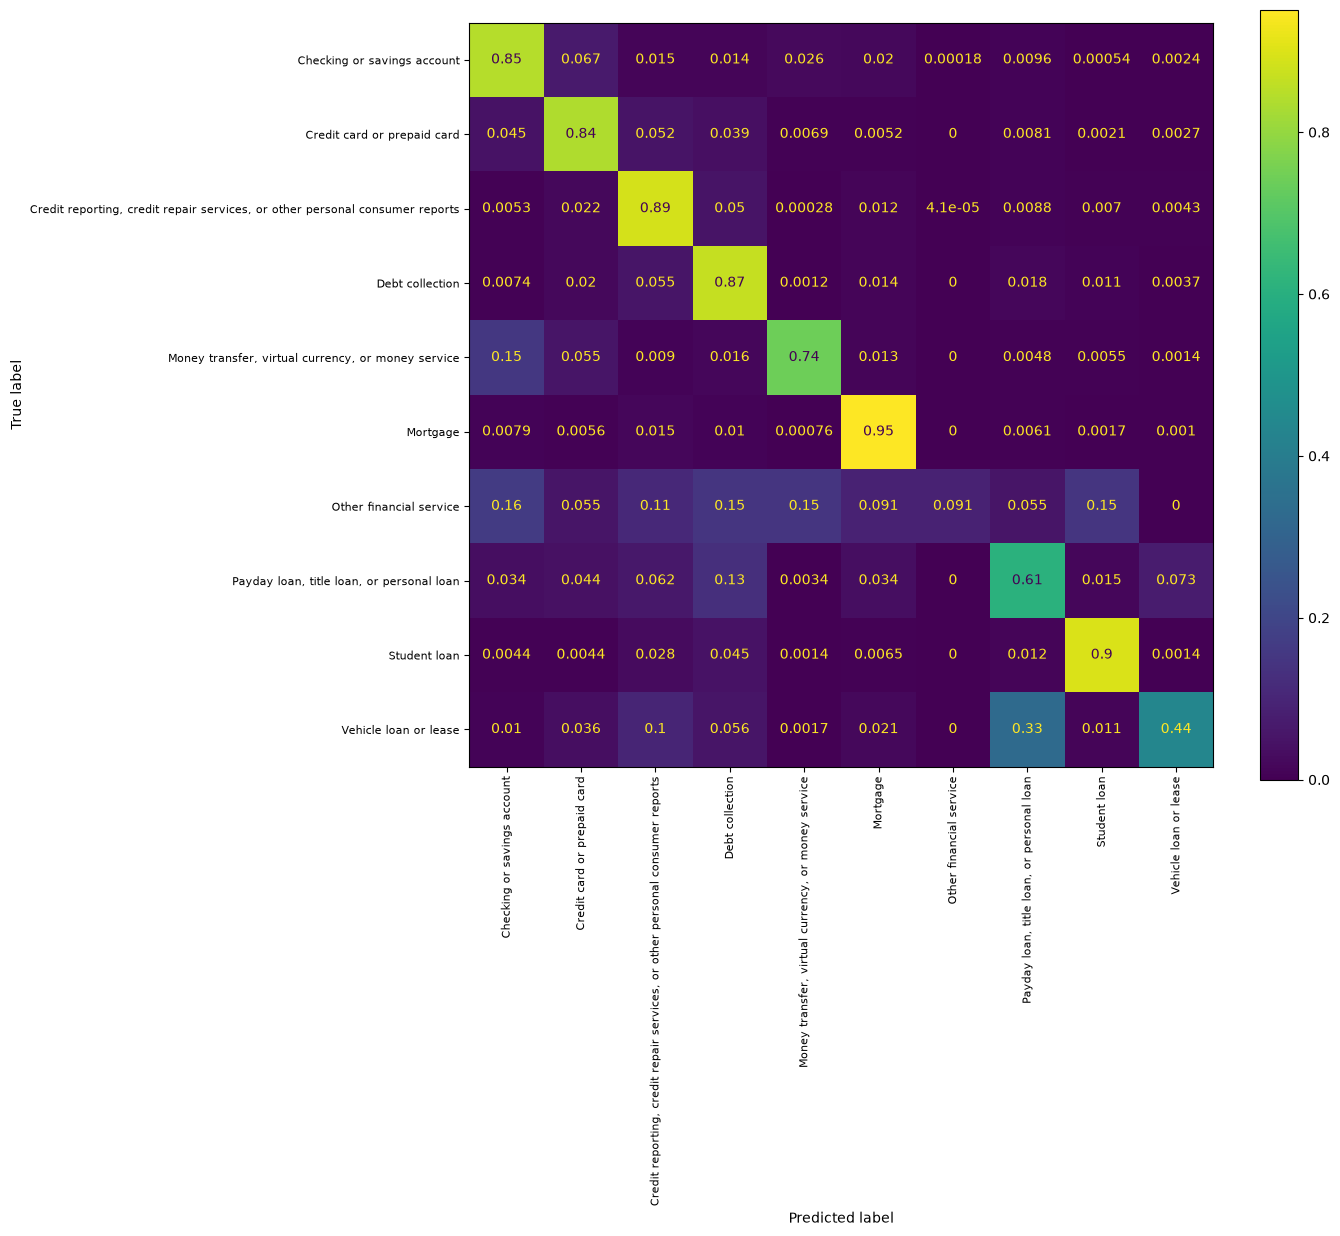

In [ ]:
# Matrice de confusion

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svc,
    xticks_rotation=90,
    normalize="true",
    ax=ax
)

ax.tick_params(axis="both", labelsize=8)

plt.show()

In [ ]:
for category in [
    "Other financial service",
    "Vehicle loan or lease",
    "Payday loan, title loan, or personal loan"
]:
    print("\n", "=" * 80)
    print(category)

    display(
        errors[
            errors["Attendue"] == category
        ][
            ["Question", "Réponse"]
        ].head(20)
    )


Other financial service


,Question,Réponse
1455,Returning to the XXXX I exchanged XXXX at the ...,"Money transfer, virtual currency, or money ser..."
1595,I attempted to contact Navient to discuss my s...,Student loan
2006,In XXXX of 2016 I went under contract for a ne...,Mortgage
7142,Santander Bank has not issued a refund check f...,Checking or savings account
12276,I was contacted by National Budget Planners an...,Student loan
15726,I was notified by a creditor that my personal ...,"Credit reporting, credit repair services, or o..."
16445,Centegy has on multipal occasions denied my pa...,Checking or savings account
16642,I was initially denied the ability to cash a c...,"Money transfer, virtual currency, or money ser..."
17240,I contacted XXXX for student loan consolidat...,Student loan
18276,"First off, the money is not lost or stolen. It...","Money transfer, virtual currency, or money ser..."



Vehicle loan or lease


,Question,Réponse
81,I was sent a letter from XXXX XXXX XXXXXXXX de...,Debt collection
247,RE : Capital One Auto Loan From XX/XX/XXXX- XX...,"Payday loan, title loan, or personal loan"
313,I purchased an used car at XXXX XXXX and was ...,"Payday loan, title loan, or personal loan"
350,My spouse and I both have Chase Auto Credit lo...,"Payday loan, title loan, or personal loan"
500,I applied directly with XXXX this a.m. of XXXX...,"Credit reporting, credit repair services, or o..."
630,I have an auto loan through USAA. I made an ad...,Mortgage
715,A Santander Consumer account that was open in ...,"Credit reporting, credit repair services, or o..."
769,I recently relocated to XXXX XXXX XXXX for wor...,"Payday loan, title loan, or personal loan"
884,XXXX XXXX XXXX hasn't removed 3 claimed late p...,"Credit reporting, credit repair services, or o..."
923,cap-one finance has this excellent program tha...,"Payday loan, title loan, or personal loan"



Payday loan, title loan, or personal loan


,Question,Réponse
4,"On XXXX XXXX, XXXX, we turned-over our XXXX XX...",Vehicle loan or lease
52,NISSAN MOTOR ACCEPTANCE has sold this account ...,Debt collection
63,To Whom it may Concern On XXXX XXXX XXXX XXXX ...,Vehicle loan or lease
64,My name is XXXX XXXX XXXX. I sent Tower Loan a...,Debt collection
137,An outside company keeps calling me and threat...,Debt collection
158,I am an Amazon Prime customer & I purchased a ...,Credit card or prepaid card
311,XXXX XXXX from XXXX ..she said she was calling...,Debt collection
394,Will call several times a day although permiss...,Debt collection
443,My payment is listed as 30 days late on XXXX c...,"Credit reporting, credit repair services, or o..."
475,I took out a SAM 's club credit account with S...,Credit card or prepaid card


# Essai de déterminer si la marge de décision peut être un indicateur de score

In [ ]:
scores = svm.decision_function(errors["Question"])

import numpy as np

sorted_scores = np.sort(scores, axis=1)

errors["Score"] = (
    sorted_scores[:, -1]
    - sorted_scores[:, -2]
)

In [ ]:
# regarder les erreurs les plus incertaines
# permet de voir si les erreurs sont associées à une faible marge
errors[
    errors["Attendue"] != errors["Réponse"]
].sort_values("margin")[
    ["Question", "Attendue", "Réponse", "Score"]
].head(30)

In [ ]:
# comparer la marge des prédictions correctes et incorrectes
errors.groupby("Correct")["Score"].describe()

comparer la marge des prédictions correctes et incorrectes

Si on obtient par exemple :

correct = False
marge médiane = faible

correct = True
marge médiane = élevée

alors on aura une preuve que la marge constitue effectivement un bon indicateur d'incertitude.
Ensuite seulement, il faut rechercher un seuil.

Tester particulièrement le cas **Other financial service**

Les réclamations Other financial service ont-elles généralement une faible marge ?

Si oui, cela donne une piste très solide pour transformer Other financial service en mécanisme de rejet.

In [ ]:
other = errors[
    errors["Attendue"] == "Other financial service"
]

other[
    [
        "Question",
        "Réponse",
        "Score"
    ]
].sort_values("margin")